## Evaluación Regresión Lineal Simple

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import cycler

# Entrenamiento y evaluación con Scikit-Learn
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# Entrenamiento y evaluación con statsmodels y scipy
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro
plt.style.use("ggplot")

colors=["#000000", "#7d7879"]
color_cycle = cycler.cycler(color=colors)

# Set the default color cycle
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "axes.prop_cycle": color_cycle
})

In [7]:
df = pd.read_csv('./publicidad.csv')

In [8]:
# Crear variables "x" (variable predictora) y "y" (variable a predecir)
x = df['TV'].to_numpy()
y = df['ventas'].to_numpy()

# Entrenar modelo de regresión lineal en statsmodels
x = sm.add_constant(x) # Añadir intercepto (y_hat = b0 + b1.x)
mod_lin = sm.OLS(y,x).fit() # Entrenar modelo


In [9]:
mod_lin.params

array([7.03259355, 0.04753664])

In [10]:
residuales = mod_lin.resid

📊 Prueba Shapiro-Wilk para los residuales
  p = 0.2133255144 ✅ No se rechaza H₀ (p>=0.05): NORMAL



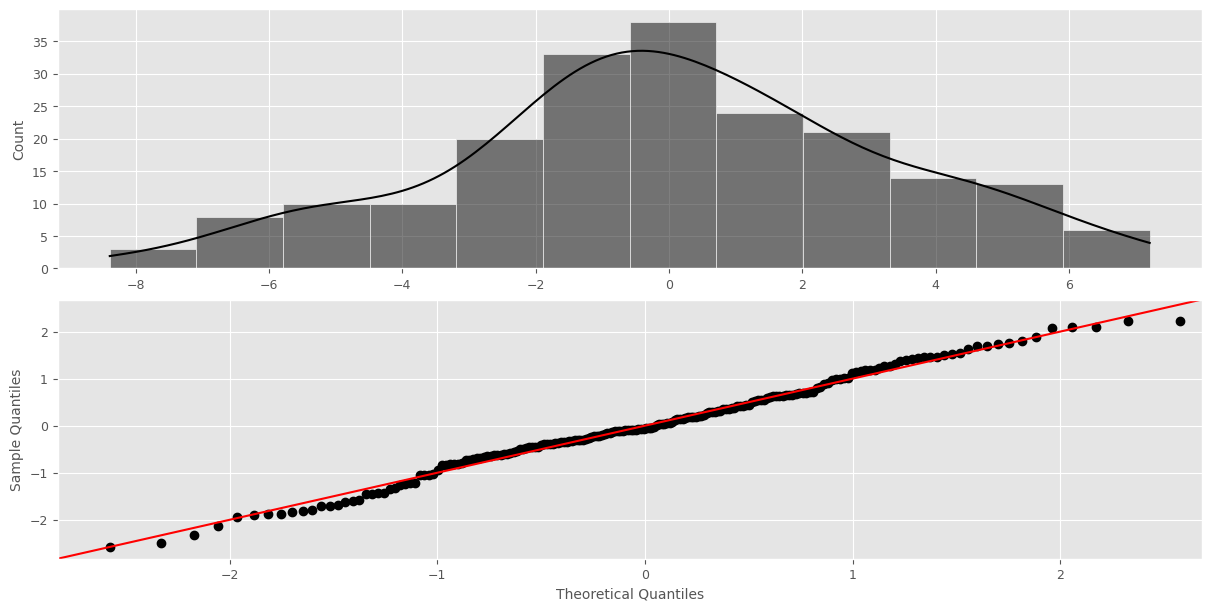

In [11]:
fig, axs = plt.subplots(2,1, figsize=(12,6))

sns.histplot(residuales, ax=axs[0], kde=True)
qqplot(residuales, line="45", fit=True, ax=axs[1]);

# Prueba Shapiro-Wilk
W, p_shapiro = shapiro(residuales)
print(f"📊 Prueba Shapiro-Wilk para los residuales")
print(f"  p = {p_shapiro:.10f} {'❌ Rechazar H₀ (p<0.05): NO-NORMAL' if p_shapiro < 0.05 else '✅ No se rechaza H₀ (p>=0.05): NORMAL'}\n")

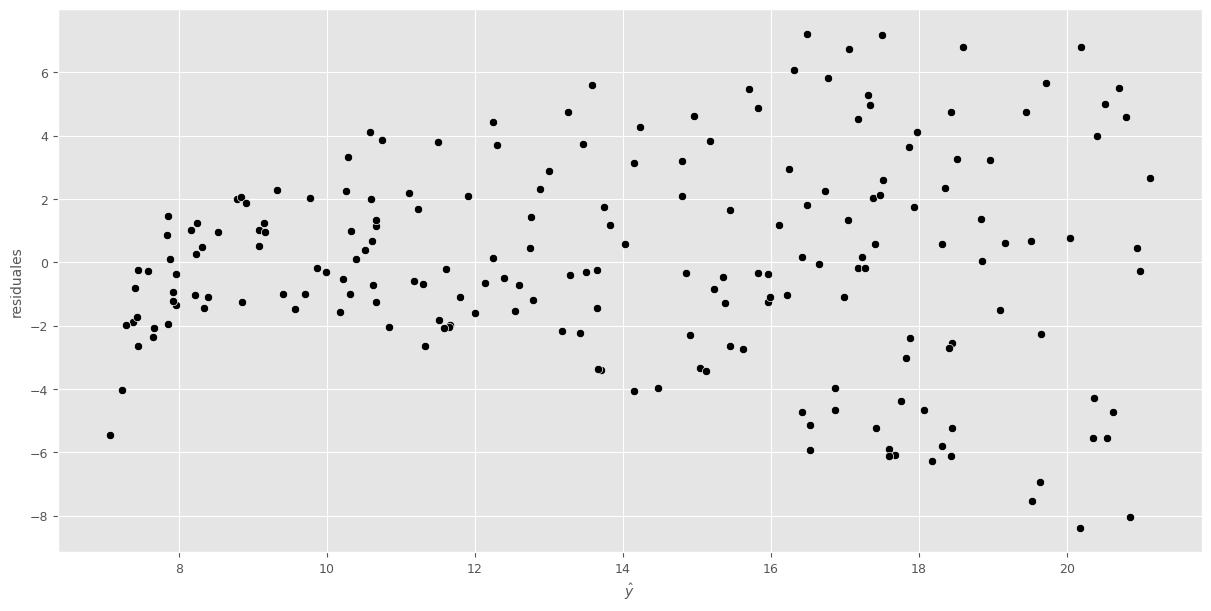

In [12]:
# Valores predichos por el modelo (y_hat)
y_hat = mod_lin.fittedvalues

# Residuales vs. predicciones
fig, ax = plt.subplots()
sns.scatterplot(x=y_hat, y=residuales),
ax.set_xlabel('$\hat{y}$')
ax.set_ylabel('residuales');

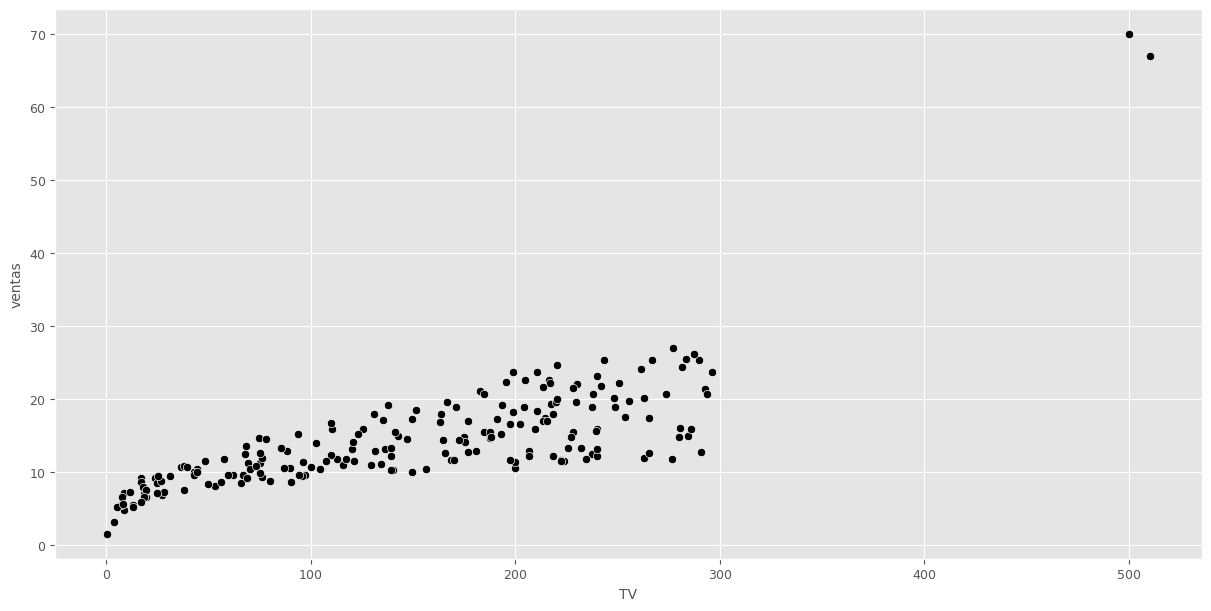

In [13]:
df_copy = df.copy()

# Nuevos datos (outliers)
outliers = pd.DataFrame({
    "TV": [500, 510],
    "ventas": [70, 67]
})

df_copy = pd.concat([df_copy, outliers], ignore_index=True)

# Gráfico de dispersión
sns.scatterplot(df_copy, x="TV", y="ventas");

In [14]:
# Crear variables "x" (variable predictora) y "y" (variable a predecir)
x = df_copy['TV'].to_numpy()
y = df_copy['ventas'].to_numpy()

# Entrenar modelo de regresión lineal en statsmodels
x = sm.add_constant(x) # Añadir intercepto
mod_lin_out = sm.OLS(y,x).fit() # Entrenar modelo

# Parámetros del modelo
mod_lin_out.params

array([5.08104721, 0.06295933])

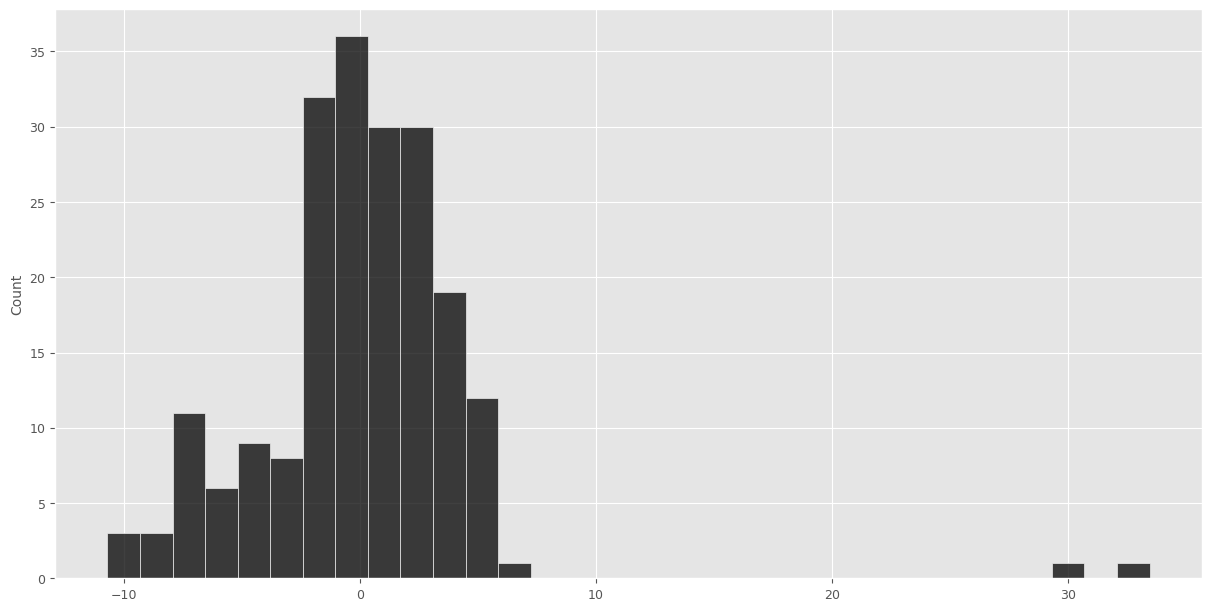

In [15]:
residuales_out = mod_lin_out.resid

fig, ax = plt.subplots()
sns.histplot(residuales_out);